# K10_01 - MNIST: Bildklassifikation mit einem CNN

## Lernziele
Nach diesem Notebook koennen Sie:
- erklaeren, warum CNNs fuer Bilddaten besser geeignet sind als Feedforward-Netze
- die Layer `Conv2D` und `MaxPooling2D` erklaeren und ihre Ausgabedimensionen berechnen
- ein CNN mit Keras aufbauen, kompilieren und trainieren
- Lernkurven und Konfusionsmatrix eines CNNs interpretieren
- CNN und Feedforward-Netz quantitativ vergleichen (Parameter, Accuracy, Laufzeit)


## Didaktischer Fokus

Leitfrage:
> Warum erreicht ein CNN mit **weniger Parametern** eine **hoehere Accuracy**
> als das Feedforward-Netz aus K10_00?

**Drei neue Konzepte gegenueber K10_00:**

| Konzept | Bedeutung |
|---|---|
| `Conv2D` | Erkennt lokale Muster durch Faltung |
| `MaxPooling2D` | Reduziert Dimension, haelt wichtige Merkmale |
| Kanalformat `(H, W, C)` | CNNs erwarten 3D-Eingabe, nicht 2D |

**Wichtige Vergleichszahlen aus K10_00:**
- Feedforward: **203.530 Parameter** → ~97-98% Test-Accuracy
- CNN (dieses Notebook): **121.930 Parameter** → ~98-99% Test-Accuracy
- CNN braucht 40% weniger Parameter und ist trotzdem besser.


## Imports und Reproduzierbarkeit


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Seeds ganz am Anfang setzen
np.random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
tf.random.set_seed(42)

from tensorflow import keras
from tensorflow.keras import layers

print('Alle Bibliotheken geladen.')
print(f'TensorFlow-Version: {tf.__version__}')


Alle Bibliotheken geladen.
TensorFlow-Version: 2.19.0


## 1. Warum ein CNN?

Im Feedforward-Netz (K10_00) haben wir das Bild mit `Flatten()` in einen
1D-Vektor umgewandelt. Das hat einen fundamentalen Nachteil:

```
28x28 Bild → Flatten → 784 Werte

Pixel (Zeile 3, Spalte 5) und Pixel (Zeile 4, Spalte 5)
sind im Bild Nachbarn.
Im Vektor liegen sie 28 Positionen auseinander.
Das Netz sieht diese Nachbarschaft nicht mehr.
```

**Die Idee des CNN:**
Statt das Bild zu einem Vektor zu machen, arbeitet ein CNN
direkt auf dem **2D-Bild**. Kleine **Filter** (z. B. 3x3 Pixel)
gleiten ueber das Bild und erkennen lokale Muster:

```
Filter 1: erkennt senkrechte Kanten  |  |
Filter 2: erkennt waagerechte Kanten ---
Filter 3: erkennt Boegen             )
...
```

Diese lokalen Muster sind **positionsunabhaengig**:
Ein Bogen in der oberen linken Ecke wird genauso erkannt
wie ein Bogen in der unteren rechten Ecke.
Das nennt man **Translationsinvarianz** —
eine Eigenschaft die Feedforward-Netze nicht haben.


## 2. MNIST-Datensatz laden


In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f'Trainingsdaten: {X_train_full.shape}  |  Labels: {y_train_full.shape}')
print(f'Testdaten:      {X_test.shape}  |  Labels: {y_test.shape}')
print(f'Pixelwertbereich: [{X_train_full.min()}, {X_train_full.max()}]')


Trainingsdaten: (60000, 28, 28)  |  Labels: (60000,)
Testdaten:      (10000, 28, 28)  |  Labels: (10000,)
Pixelwertbereich: [0, 255]


## 3. Datenvorverarbeitung

### Normalisierung
Identisch zu K10_00: Pixelwerte von [0, 255] auf [0, 1] skalieren.

### Kanalformat fuer CNNs
Ein CNN erwartet Eingaben der Form `(Hoehe, Breite, Kanaele)`.
Bei MNIST (Graustufen) bedeutet das: `(28, 28, 1)`.

```
Feedforward-Netz (K10_00):   (28, 28)    → Flatten → 784
CNN (dieses Notebook):       (28, 28, 1) → Conv2D direkt auf 2D-Bild
```

Der Kanal-Wert 1 steht fuer Graustufen.
Bei RGB-Farbbildern waere es 3 (Rot, Gruen, Blau).


In [ ]:
# Normalisierung
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0

# Kanalformat: (28, 28) -> (28, 28, 1)
X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test       = X_test.reshape(-1, 28, 28, 1)

print(f'Trainingsdaten nach Reshape: {X_train_full.shape}')
print(f'Testdaten nach Reshape:      {X_test.shape}')
print(f'Pixelwerte: [{X_train_full.min():.1f}, {X_train_full.max():.1f}]')


Trainingsdaten nach Reshape: (60000, 28, 28, 1)
Testdaten nach Reshape:      (10000, 28, 28, 1)
Pixelwerte: [0.0, 1.0]


## 4. Beispielbilder visualisieren


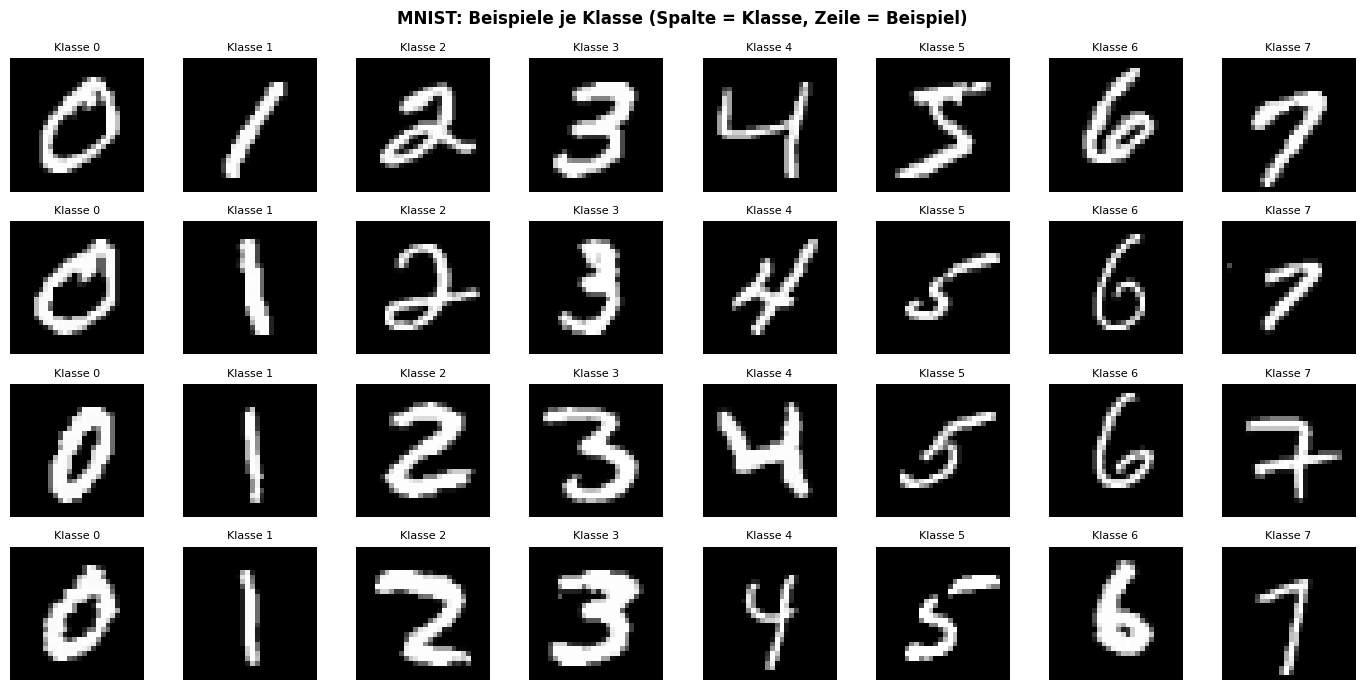

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(14, 7))

for row, digit in enumerate(range(8)):
    idxs = np.where(y_train_full.ravel() == digit)[0][:4]
    for col, idx in enumerate(idxs):
        axes[col, row].imshow(X_train_full[idx, :, :, 0], cmap='gray')
        axes[col, row].set_title(f'Klasse {digit}', fontsize=8)
        axes[col, row].axis('off')

plt.suptitle('MNIST: Beispiele je Klasse (Spalte = Klasse, Zeile = Beispiel)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Train/Validierungs-Split

Identisch zu K10_00: 90% Training, 10% Validierung.
Testdaten bleiben unangetastet.


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1, random_state=42, stratify=y_train_full
)

print(f'Trainingsdaten:    {X_train.shape}')
print(f'Validierungsdaten: {X_val.shape}')
print(f'Testdaten:         {X_test.shape}')


Trainingsdaten:    (54000, 28, 28, 1)
Validierungsdaten: (6000, 28, 28, 1)
Testdaten:         (10000, 28, 28, 1)


## 6. Die neuen Layer: Conv2D und MaxPooling2D

### Conv2D — Faltungsschicht

Ein `Conv2D(32, (3,3))`-Layer verwendet **32 Filter**, jeder 3x3 Pixel gross.
Jeder Filter gleitet ueber das gesamte Bild und berechnet eine gewichtete Summe:

```
Eingabe (Ausschnitt):     Filter (3x3):     Ergebnis:
[ 0,  0, 128]            [ 1,  0, -1]       0*1 + 0*0 + 128*(-1)
[ 0, 255,  0]         x  [ 1,  0, -1]     + 0*1 + 255*0 + 0*(-1)
[128,  0,  0]            [ 1,  0, -1]     + 128*1 + 0*0 + 0*(-1)
                                          = -128 + 0 + 128 = 0
```

Dieser Filter erkennt senkrechte Kanten. Das Netz **lernt automatisch**,
welche Filter nuetzlich sind — wir geben nur die Anzahl vor (hier: 32).

**Ausgabedimension nach Conv2D(32, (3,3)):**
```
Eingabe: (28, 28, 1)
Ausgabe: (26, 26, 32)   <- 28-3+1=26, 32 Filterkarten
```

### MaxPooling2D — Poolingschicht

`MaxPooling2D(2,2)` teilt das Bild in 2x2-Bloecke auf
und behaelt nur den **groessten Wert** pro Block:

```
Eingabe (4x4):          Nach MaxPool(2x2):
[ 1,  3,  2,  4]        [ 3,  4]
[ 5,  6,  1,  2]   →    [ 6,  8]
[ 1,  2,  8,  1]
[ 0,  1,  3,  2]
```

Vorteile: weniger Parameter, robuster gegenueber kleinen Verschiebungen.

**Ausgabedimension nach MaxPooling2D(2,2):**
```
Eingabe: (26, 26, 32)
Ausgabe: (13, 13, 32)   <- Halbierung in H und W
```

### Dimensionen durch das gesamte CNN

```
Eingabe:                  (28, 28,  1)
Conv2D(32, 3x3):          (26, 26, 32)   <- -2 pro Dimension
MaxPooling2D(2x2):        (13, 13, 32)   <- Halbierung
Conv2D(64, 3x3):          (11, 11, 64)   <- -2 pro Dimension
MaxPooling2D(2x2):        ( 5,  5, 64)   <- Halbierung
Flatten:                  1600           <- 5*5*64
Dense(64):                  64
Dense(10, softmax):         10           <- eine Klasse pro Ziffer
```


**Mini-Uebung 1:** Berechnen Sie die Ausgabedimension nach jedem Layer.
- Was waere die Ausgabe nach Conv2D(32, (5,5)) statt (3,3)?
- Warum hat Flatten keine lernbaren Parameter?
- Was bedeutet die 64 in Conv2D(64, ...)?


## 7. CNN definieren und kompilieren


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='CNN_MNIST')

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "CNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

### Parameteranzahl — der entscheidende Vergleich

```
CNN (dieses Notebook):
  Conv2D(32):   3 x 3 x 1 x 32  + 32  =      320 Parameter
  MaxPool:                             =        0 Parameter
  Conv2D(64):   3 x 3 x 32 x 64 + 64  =   18.496 Parameter
  MaxPool:                             =        0 Parameter
  Flatten:      5 x 5 x 64 = 1600 Eingaben
  Dense(64):    1600 x 64  + 64        =  102.464 Parameter
  Dense(10):    64   x 10  + 10        =      650 Parameter
  Gesamt:                              =  121.930 Parameter

Feedforward (K10_00):                  =  203.530 Parameter

CNN hat 40% WENIGER Parameter
und erreicht trotzdem hoehere Accuracy.
```

**Warum?** Der CNN nutzt **gemeinsame Gewichte** (weight sharing):
Derselbe Filter wird an jeder Position des Bildes verwendet.
Das Feedforward-Netz hat fuer jede Pixel-Neuron-Verbindung ein eigenes Gewicht.


**Mini-Uebung 2:** Schauen Sie auf model.summary().
- Warum haben die MaxPooling-Layer keine Parameter?
- Welcher Layer hat die meisten Parameter? Warum?
- Was passiert mit den Dimensionen nach jedem Layer?


## 8. Early Stopping

Identisch zu K10_00: Training stoppt wenn Val-Loss sich
nicht mehr verbessert. `restore_best_weights=True` setzt
die Gewichte auf die beste Epoche zurueck.


In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print('Early Stopping: monitor=val_loss, patience=3, restore_best_weights=True')


Early Stopping: monitor=val_loss, patience=3, restore_best_weights=True


## 9. CNN trainieren

Wir messen die Laufzeit fuer den direkten Vergleich mit dem
Feedforward-Netz aus K10_00.

CNNs sind in der Regel langsamer pro Epoche als Feedforward-Netze
(mehr Rechenoperationen durch die Faltung) — aber konvergieren
oft in weniger Epochen bei hoeherer Accuracy.


In [ ]:
start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=2
)

end_time      = time.time()
laufzeit      = end_time - start_time
stopped_epoch = len(history.history['loss'])

print(f'Training beendet nach {stopped_epoch} Epochen.')
print(f'Laufzeit gesamt:    {laufzeit:.1f} Sekunden')
print(f'Laufzeit pro Epoch: {laufzeit/stopped_epoch:.2f} Sekunden')
print(f'Beste Val-Accuracy: {max(history.history["val_accuracy"]):.4f}')
print(f'Beste Val-Loss:     {min(history.history["val_loss"]):.4f}')


Epoch 1/20
422/422 - 38s - 90ms/step - accuracy: 0.9311 - loss: 0.2368 - val_accuracy: 0.9748 - val_loss: 0.0923
Epoch 2/20
422/422 - 37s - 87ms/step - accuracy: 0.9810 - loss: 0.0629 - val_accuracy: 0.9790 - val_loss: 0.0812
Epoch 3/20
422/422 - 37s - 88ms/step - accuracy: 0.9862 - loss: 0.0447 - val_accuracy: 0.9837 - val_loss: 0.0616
Epoch 4/20
422/422 - 35s - 83ms/step - accuracy: 0.9890 - loss: 0.0357 - val_accuracy: 0.9863 - val_loss: 0.0529
Epoch 5/20
422/422 - 42s - 100ms/step - accuracy: 0.9915 - loss: 0.0288 - val_accuracy: 0.9865 - val_loss: 0.0525
Epoch 6/20
422/422 - 36s - 86ms/step - accuracy: 0.9932 - loss: 0.0236 - val_accuracy: 0.9857 - val_loss: 0.0553
Epoch 7/20
422/422 - 35s - 84ms/step - accuracy: 0.9946 - loss: 0.0193 - val_accuracy: 0.9860 - val_loss: 0.0551
Epoch 8/20
422/422 - 42s - 100ms/step - accuracy: 0.9957 - loss: 0.0156 - val_accuracy: 0.9860 - val_loss: 0.0505
Epoch 9/20
422/422 - 37s - 87ms/step - accuracy: 0.9959 - loss: 0.0137 - val_accuracy: 0.9860 

## 10. Lernkurven analysieren

Vergleichen Sie diese Kurven mit den Lernkurven aus K10_00:
- Konvergiert das CNN schneller oder langsamer?
- Ist der Abstand zwischen Train und Val groesser oder kleiner?


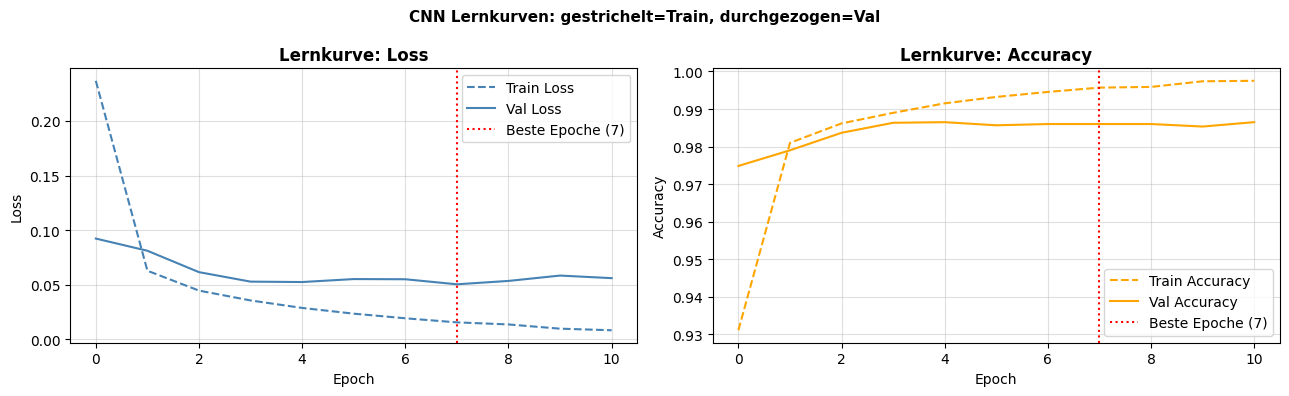

In [ ]:
hist_df = pd.DataFrame(history.history)
best_epoch = hist_df['val_loss'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_df['loss'],     color='steelblue', linestyle='--', label='Train Loss')
axes[0].plot(hist_df['val_loss'], color='steelblue', linestyle='-',  label='Val Loss')
axes[0].axvline(x=best_epoch, color='red', linestyle=':', label=f'Beste Epoche ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Lernkurve: Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(hist_df['accuracy'],     color='orange', linestyle='--', label='Train Accuracy')
axes[1].plot(hist_df['val_accuracy'], color='orange', linestyle='-',  label='Val Accuracy')
axes[1].axvline(x=best_epoch, color='red', linestyle=':', label=f'Beste Epoche ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Lernkurve: Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('CNN Lernkurven: gestrichelt=Train, durchgezogen=Val',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


**Mini-Uebung 3:** Interpretieren Sie die Lernkurven.
- Nach wie vielen Epochen hat Early Stopping gestoppt?
- Wie gross ist der Abstand zwischen Train und Val?
- Vergleichen Sie mit den K10_00-Lernkurven: Was faellt auf?


## 11. Finale Evaluation auf Testdaten


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f'Test-Loss:     {test_loss:.4f}')
print(f'Test-Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Val-Accuracy:  {max(history.history["val_accuracy"]):.4f}  (zum Vergleich)')
print()
print(f'Korrekt:       {int(test_acc*10000)} von 10.000 Bildern')
print(f'Fehler:        {int((1-test_acc)*10000)} von 10.000 Bildern')


Test-Loss:     0.0370
Test-Accuracy: 0.9890  (98.90%)
Val-Accuracy:  0.9865  (zum Vergleich)

Korrekt:       9890 von 10.000 Bildern
Fehler:        109 von 10.000 Bildern


## 12. Konfusionsmatrix


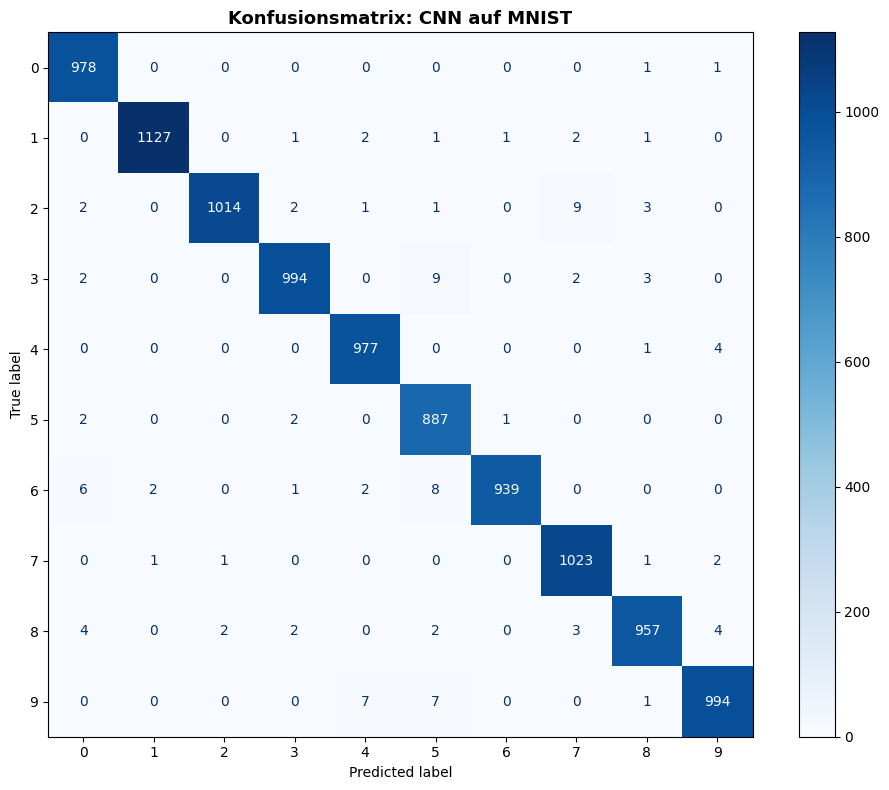

Top-5 Verwechslungspaare (Wahr -> Vorhergesagt | Anzahl):
  2 -> 7 : 9 Mal
  3 -> 5 : 9 Mal
  6 -> 5 : 8 Mal
  9 -> 5 : 7 Mal
  9 -> 4 : 7 Mal


In [ ]:
y_pred_prob    = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(
    ax=ax, cmap='Blues', colorbar=True
)
ax.set_title('Konfusionsmatrix: CNN auf MNIST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat_idx = np.argsort(cm_off.ravel())[::-1][:5]
print('Top-5 Verwechslungspaare (Wahr -> Vorhergesagt | Anzahl):')
for idx in flat_idx:
    t, p = idx // 10, idx % 10
    print(f'  {t} -> {p} : {cm_off[t,p]} Mal')


## 13. Fehlklassifikationen visualisieren


Fehlklassifikationen: 110 von 10000 (1.10%)


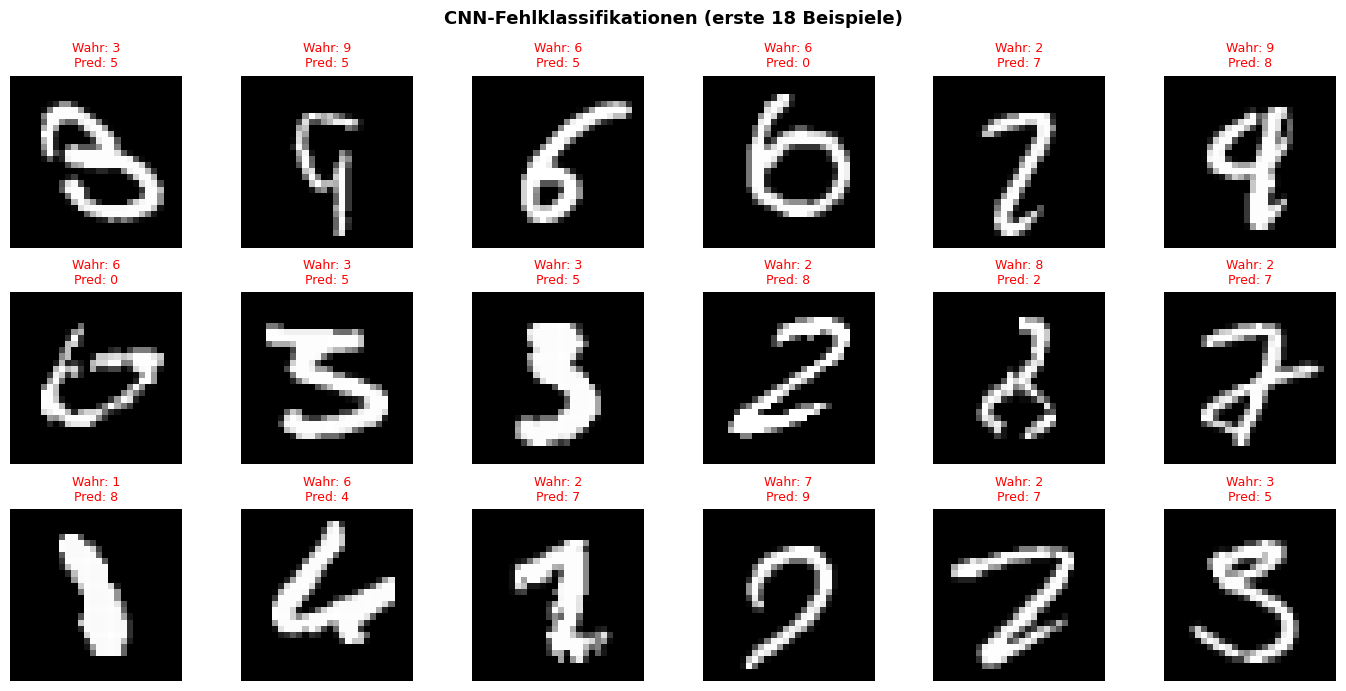

In [ ]:
errors = np.where(y_pred_classes != y_test)[0]
print(f'Fehlklassifikationen: {len(errors)} von {len(y_test)} ({len(errors)/len(y_test)*100:.2f}%)')

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
for ax, idx in zip(axes.ravel(), errors[:18]):
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(
        f'Wahr: {y_test[idx]}\nPred: {y_pred_classes[idx]}',
        color='red', fontsize=9
    )
    ax.axis('off')

plt.suptitle('CNN-Fehlklassifikationen (erste 18 Beispiele)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Mini-Uebung 4:** Vergleichen Sie die CNN-Fehler mit den K10_00-Fehlern.
- Gibt es Faelle die das CNN noch falsch klassifiziert, das Feedforward-Netz aber auch?
- Sind die CNN-Fehler 'schwieriger' als die Feedforward-Fehler?
- Was koennte auch ein CNN nicht loesen?


## 14. Direktvergleich: Feedforward-Netz vs. CNN

Fuehren Sie diese Zelle aus nachdem Sie K10_00 ausgefuehrt haben
und notieren Sie die Werte aus beiden Notebooks:


              Modell  Parameter  Test-Acc  Laufzeit (s)
Feedforward (K10_00)     203530     0.977          30.0
        CNN (K10_01)     121930     0.989         415.3


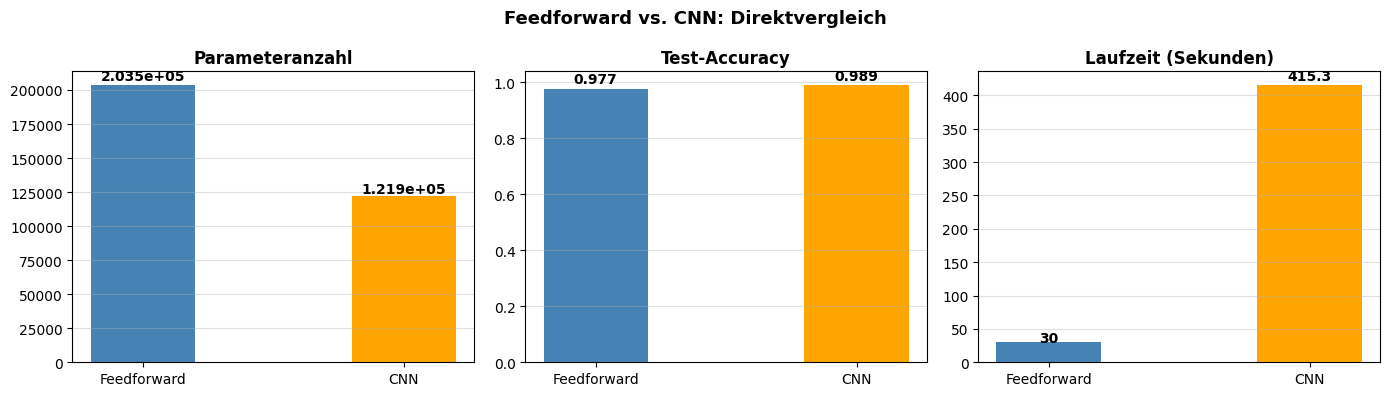

In [ ]:
# Werte aus K10_00 manuell eintragen (nach Ausfuehren von K10_00)
ff_params   = 203530
ff_accuracy = 0.977   # <- Ihren Wert aus K10_00 eintragen
ff_laufzeit = 30.0    # <- Ihren Wert aus K10_00 eintragen (Sekunden)

cnn_params   = model.count_params()
cnn_accuracy = test_acc
cnn_laufzeit = laufzeit

vergleich = pd.DataFrame({
    'Modell':      ['Feedforward (K10_00)', 'CNN (K10_01)'],
    'Parameter':   [ff_params, cnn_params],
    'Test-Acc':    [round(ff_accuracy,4), round(cnn_accuracy,4)],
    'Laufzeit (s)':[round(ff_laufzeit,1), round(cnn_laufzeit,1)]
})
print(vergleich.to_string(index=False))

# Barplot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, titel in zip(
    axes,
    ['Parameter', 'Test-Acc', 'Laufzeit (s)'],
    ['Parameteranzahl', 'Test-Accuracy', 'Laufzeit (Sekunden)']
):
    bars = ax.bar(['Feedforward', 'CNN'],
                  vergleich[col],
                  color=['steelblue', 'orange'], width=0.4)
    for bar, val in zip(bars, vergleich[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{val:,.4g}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(titel, fontweight='bold')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Feedforward vs. CNN: Direktvergleich',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 15. Fazit

**Was das CNN besser macht:**
- `Conv2D` erkennt **lokale Muster** (Kanten, Boegen, Ecken) direkt im 2D-Bild
- **Translationsinvarianz**: ein Muster wird erkannt, egal wo im Bild es ist
- **Weight Sharing**: derselbe Filter wird ueberall angewendet → weniger Parameter

**Quantitativer Vorteil:**
- 40% weniger Parameter als das Feedforward-Netz
- trotzdem hoehere Accuracy (~98-99% vs ~97-98%)

**Wann ist das CNN langsamer?**
- Pro Epoche: mehr Rechenoperationen durch die Faltung
- Gesamt: oft aehnlich oder schneller weil weniger Epochen benoetigt

> **Kernbotschaft:** CNNs sind nicht einfach 'groesser' als Feedforward-Netze.
> Sie sind **anders strukturiert** — sie nutzen das Wissen ueber die
> raeumliche Struktur von Bildern aus. Das macht sie effizienter und genauer.


## 16. Uebungsaufgaben

**Aufgabe 1 – Konzepte erklaeren**
Erklaeren Sie in eigenen Worten:
- Was berechnet `Conv2D` konkret?
- Warum hat `MaxPooling2D` keine lernbaren Parameter?
- Was bedeutet Translationsinvarianz?

**Aufgabe 2 – Architektur variieren**
Veraendern Sie das CNN und vergleichen Sie Accuracy und Laufzeit:
- Fuegen Sie einen dritten `Conv2D`-Layer hinzu (z. B. Conv2D(128, (3,3)))
- Entfernen Sie ein MaxPooling2D
- Reduzieren Sie auf Conv2D(16) + Conv2D(32)

**Aufgabe 3 – Parameterberechnung**
Berechnen Sie von Hand:
- Wie viele Parameter hat Conv2D(32, (5,5)) mit Input (28,28,1)?
- Welche Ausgabedimension hat Conv2D(64, (3,3)) nach einem Input von (13,13,32)?

**Aufgabe 4 – Vergleich und Reflexion**
- Warum hat das CNN weniger Parameter als das Feedforward-Netz,
  obwohl es eine komplexere Architektur hat?
- In welchen Faellen wuerde ein Feedforward-Netz einem CNN vorzuziehen sein?
- Wann stossen auch CNNs an ihre Grenzen?


In [ ]:
# Aufgabe 2 - CNN variieren
model_variante = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64,  kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(128, kernel_size=(3,3), activation='relu'),  # <- neuer Layer
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='CNN_Variante')

model_variante.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
history_v = model_variante.fit(
    X_train, y_train,
    epochs=20, batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )],
    verbose=0
)
lz_v = time.time() - t0

_, acc_v = model_variante.evaluate(X_test, y_test, verbose=0)

vergleich2 = pd.DataFrame({
    'Modell':      ['Basismodell CNN', 'CNN Variante'],
    'Parameter':   [model.count_params(), model_variante.count_params()],
    'Epochen':     [stopped_epoch, len(history_v.history['loss'])],
    'Test-Acc':    [round(test_acc,4), round(acc_v,4)],
    'Laufzeit (s)':[round(laufzeit,1), round(lz_v,1)]
})
print(vergleich2.to_string(index=False))


         Modell  Parameter  Epochen  Test-Acc  Laufzeit (s)
Basismodell CNN     121930       11    0.9890         415.3
   CNN Variante     167114       10    0.9916         412.4
